/data/kang/vlmloc/obj_refer_data/2013_05_28_drive_0010_sync_centers_info.pkl: 309 frames, avg_nodes=31.38, unique labels=20
/data/kang/vlmloc/data/k360_50-10_gridCells_pd10_pc2_shiftPoses_all_nm-6/2013_05_28_drive_0010_sync_centers_info.pkl: 300 frames, avg_nodes=34.73, unique labels=19


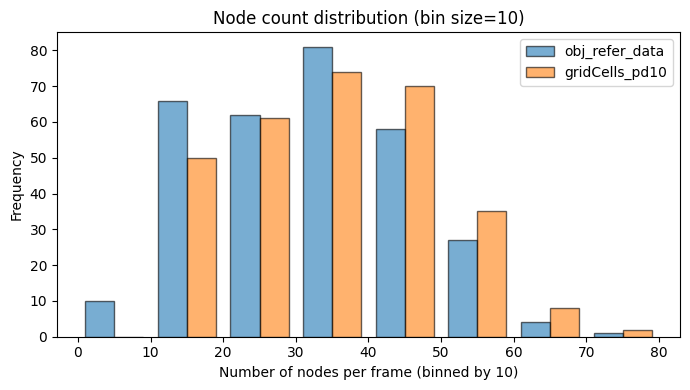


=== obj_refer_data (Node Count Distribution) ===
  0–  9: 10
 10– 19: 66
 20– 29: 62
 30– 39: 81
 40– 49: 58
 50– 59: 27
 60– 69: 4
 70– 79: 1

=== gridCells_pd10 (Node Count Distribution) ===
  0–  9: 0
 10– 19: 50
 20– 29: 61
 30– 39: 74
 40– 49: 70
 50– 59: 35
 60– 69: 8
 70– 79: 2


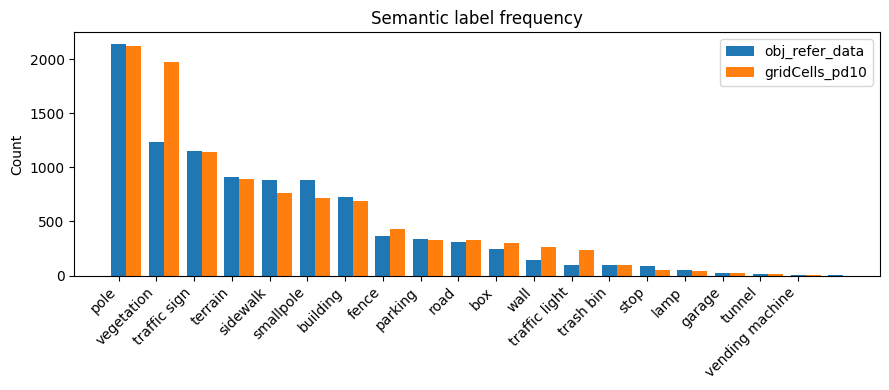


=== obj_refer_data (Top Semantic Labels) ===
pole                 : 2140
vegetation           : 1231
traffic sign         : 1149
terrain              : 910
building             : 886
sidewalk             : 881
smallpole            : 722
parking              : 370
road                 : 336
box                  : 311
traffic light        : 242
fence                : 141
wall                 : 102
trash bin            : 94
stop                 : 88
lamp                 : 48
garage               : 25
tunnel               : 11
vending machine      : 5
bridge               : 3

=== gridCells_pd10 (Top Semantic Labels) ===
pole                 : 2117
vegetation           : 1970
traffic sign         : 1139
terrain              : 890
sidewalk             : 764
smallpole            : 716
building             : 687
fence                : 434
parking              : 333
road                 : 332
box                  : 304
wall                 : 264
traffic light        : 239
trash bin           

In [11]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# 文件路径
paths = [
    '/data/kang/vlmloc/obj_refer_data/2013_05_28_drive_0010_sync_centers_info.pkl',
    '/data/kang/vlmloc/data/k360_50-10_gridCells_pd10_pc2_shiftPoses_all_nm-6/2013_05_28_drive_0010_sync_centers_info.pkl',
]
labels = ["obj_refer_data", "gridCells_pd10"]

node_counts = []
label_freqs = []

# 逐文件统计
for path in paths:
    with open(path, 'rb') as f:
        data = pickle.load(f)
    centers_info = data['centers_info']

    # 每帧节点数
    counts = [len(center) for center in centers_info if center is not None]
    node_counts.append(counts)

    # 所有节点语义类别
    label_counter = Counter()
    for center in centers_info:
        if center is None:
            continue
        for node in center:
            if isinstance(node, dict):
                label = node.get('label', 'unknown')
            elif hasattr(node, 'label'):
                label = getattr(node, 'label')
            else:
                label = 'unknown'
            label_counter[label] += 1
    label_freqs.append(label_counter)

    print(f"{path}: {len(counts)} frames, avg_nodes={np.mean(counts):.2f}, unique labels={len(label_counter)}")

# ==========================
# 节点数量分布
# ==========================
bins = np.arange(0, max(max(c) for c in node_counts) + 10, 10)
plt.figure(figsize=(7, 4))
plt.hist(node_counts, bins=bins, label=labels, alpha=0.6, edgecolor='black')
plt.xlabel("Number of nodes per frame (binned by 10)")
plt.ylabel("Frequency")
plt.title("Node count distribution (bin size=10)")
plt.legend()
plt.tight_layout()
plt.show()

# 打印频度表
for label, counts in zip(labels, node_counts):
    hist, edges = np.histogram(counts, bins=bins)
    print(f"\n=== {label} (Node Count Distribution) ===")
    for i in range(len(hist)):
        print(f"{int(edges[i]):>3d}–{int(edges[i+1]-1):>3d}: {hist[i]}")

# ==========================
# 语义类别分布
# ==========================
plt.figure(figsize=(9, 4))
for label, freq in zip(labels, label_freqs):
    keys, vals = zip(*sorted(freq.items(), key=lambda x: -x[1]))
    plt.bar(np.arange(len(keys)) + (0.4 if label == labels[1] else 0), vals,
            width=0.4, label=label)

plt.xticks(np.arange(len(keys)), keys, rotation=45, ha='right')
plt.ylabel("Count")
plt.title("Semantic label frequency")
plt.legend()
plt.tight_layout()
plt.show()

# 打印语义分布表
for label, freq in zip(labels, label_freqs):
    print(f"\n=== {label} (Top Semantic Labels) ===")
    for k, v in freq.most_common(20):
        print(f"{k:20s} : {v}")


In [3]:
import pickle
import numpy as np
import open3d as o3d

# ---------------------------
# 路径设置
# ---------------------------
cell_path = '/data/kang/vlmloc/vlmloc_data_v5/k360_50-10_gridCells_pd10_pc2_shiftPoses_all_nm-6_v5/cells/2013_05_28_drive_0000_sync.pkl'
object_path = '/data/kang/vlmloc/vlmloc_data_v5/k360_50-10_gridCells_pd10_pc2_shiftPoses_all_nm-6_v5/objects/2013_05_28_drive_0000_sync.pkl'
save_path = '/data/kang/vlmloc/filtered_points_0000_cell200_xyz.ply'

# ---------------------------
# 读取数据
# ---------------------------
with open(cell_path, 'rb') as f:
    cell_data = pickle.load(f)

with open(object_path, 'rb') as f:
    object_data = pickle.load(f)

cell = cell_data[200]
bbox = np.array(cell.bbox_w)  # [[xmin, ymin, zmin], [xmax, ymax, zmax]]

xmin, ymin, zmin = bbox[0:3]
xmax, ymax, zmax = bbox[3:6]

# ---------------------------
# 仅按 XY 平面范围筛选
# ---------------------------
points, colors = [], []

for obj in object_data:
    xyz = np.asarray(obj.xyz_raw)
    rgb = np.asarray(obj.rgb_raw)

    mask_xy = (
        (xyz[:, 0] >= xmin) & (xyz[:, 0] <= xmax) & (xyz[:, 2] <= zmax) & (xyz[:, 2] >= zmin) &
        (xyz[:, 1] >= ymin) & (xyz[:, 1] <= ymax)
    )

    if np.any(mask_xy):
        points.append(xyz[mask_xy])
        colors.append(rgb[mask_xy])

# ---------------------------
# 合并并保存
# ---------------------------
if len(points) == 0:
    print("⚠️ 没有点落在该 XY bbox 范围内。")
else:
    points = np.concatenate(points, axis=0)
    colors = np.concatenate(colors, axis=0)
    if colors.max() > 1.0:
        colors = colors / 255.0

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd.colors = o3d.utility.Vector3dVector(colors)
    o3d.io.write_point_cloud(save_path, pcd)
    print(f"✅ 已保存 {points.shape[0]} 个点到 {save_path}")


✅ 已保存 676358 个点到 /data/kang/vlmloc/filtered_points_0000_cell200_xyz.ply


In [7]:
import pickle
import numpy as np

# ---------------------------
# 路径设置
# ---------------------------
cell_path = '/data/kang/vlmloc/vlmloc_data_v2/k360_50-10_gridCells_pd10_pc2_shiftPoses_all_nm-6_1029/cells/2013_05_28_drive_0010_sync.pkl'

# ---------------------------
# 读取数据
# ---------------------------
with open(cell_path, 'rb') as f:
    cell_data = pickle.load(f)

cell = cell_data[200]
bbox = np.array(cell.bbox_w)  # [[xmin, ymin, zmin], [xmax, ymax, zmax]]
xmin, ymin = bbox[:2]
xmax, ymax = bbox[3:5]

# ---------------------------
# 遍历每个 object 并统计点数
# ---------------------------
results = []

for idx, obj in enumerate(cell.objects):
    label = getattr(obj, "label", "unknown")
    xyz = np.asarray(obj.xyz)

    # mask_xy = (
    #     (xyz[:, 0] >= xmin) & (xyz[:, 0] <= xmax) &
    #     (xyz[:, 1] >= ymin) & (xyz[:, 1] <= ymax)
    # )
    # count = int(np.sum(mask_xy))
    # if count > 0:
    results.append((idx, label, xyz.shape[0]))

# ---------------------------
# 输出结果
# ---------------------------
if not results:
    print("⚠️ 没有任何 object 落在该 cell 的 XY 范围内。")
else:
    print(f"✅ cell index 7 内各 object 点数统计：\n")
    for idx, label, count in results:
        print(f"Object {idx:4d} | Label: {label:15s} | Points: {count:8d}")


✅ cell index 7 内各 object 点数统计：

Object    0 | Label: road            | Points:     8502
Object    1 | Label: sidewalk        | Points:     2048
Object    2 | Label: sidewalk        | Points:     1891
Object    3 | Label: fence           | Points:     9681
Object    4 | Label: fence           | Points:     1192
Object    5 | Label: vegetation      | Points:    13359
Object    6 | Label: vegetation      | Points:     1384
Object    7 | Label: vegetation      | Points:      490
Object    8 | Label: vegetation      | Points:      549
Object    9 | Label: vegetation      | Points:      319
Object   10 | Label: vegetation      | Points:      340
Object   11 | Label: terrain         | Points:    10387
Object   12 | Label: terrain         | Points:      776
Object   13 | Label: terrain         | Points:      374
Object   14 | Label: pole            | Points:       39
Object   15 | Label: pole            | Points:       56
Object   16 | Label: traffic sign    | Points:       80
Object   17 | La

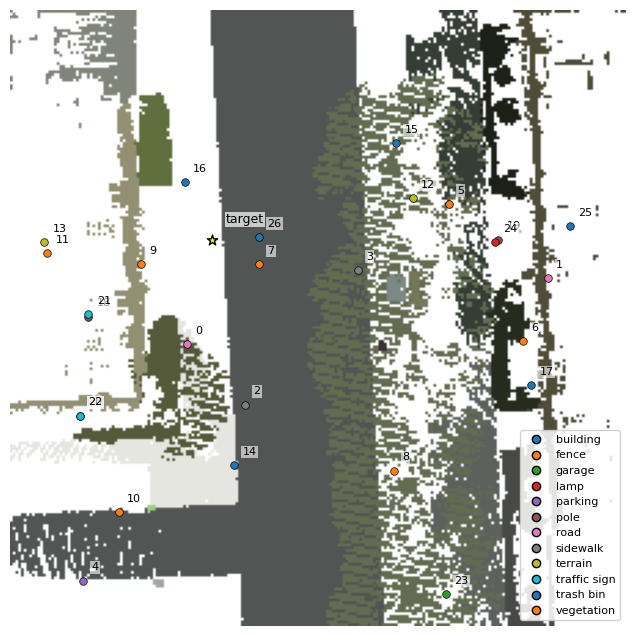

In [2]:
# --- Config: 把下面这行替换为你的本地图片路径 ---
image_path = "./vlmloc_data_v5/k360_50-10_gridCells_pd10_pc2_shiftPoses_all_nm-6_v5/bev_image/2013_05_28_drive_0010_sync/bev_000247.png"

import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from PIL import Image
from pathlib import Path

# ---------- 输入（按你给的 messages 内容） ----------
nodes_json_str = "{\"nodes\": [{\"node_id\": 0, \"label\": \"road\", \"pixel_center\": [64, 121]}, {\"node_id\": 1, \"label\": \"road\", \"pixel_center\": [195, 97]}, {\"node_id\": 2, \"label\": \"sidewalk\", \"pixel_center\": [85, 143]}, {\"node_id\": 3, \"label\": \"sidewalk\", \"pixel_center\": [126, 94]}, {\"node_id\": 4, \"label\": \"parking\", \"pixel_center\": [26, 207]}, {\"node_id\": 5, \"label\": \"fence\", \"pixel_center\": [159, 70]}, {\"node_id\": 6, \"label\": \"fence\", \"pixel_center\": [186, 120]}, {\"node_id\": 7, \"label\": \"fence\", \"pixel_center\": [90, 92]}, {\"node_id\": 8, \"label\": \"fence\", \"pixel_center\": [139, 167]}, {\"node_id\": 9, \"label\": \"fence\", \"pixel_center\": [47, 92]}, {\"node_id\": 10, \"label\": \"vegetation\", \"pixel_center\": [39, 182]}, {\"node_id\": 11, \"label\": \"vegetation\", \"pixel_center\": [13, 88]}, {\"node_id\": 12, \"label\": \"terrain\", \"pixel_center\": [146, 68]}, {\"node_id\": 13, \"label\": \"terrain\", \"pixel_center\": [12, 84]}, {\"node_id\": 14, \"label\": \"building\", \"pixel_center\": [81, 165]}, {\"node_id\": 15, \"label\": \"building\", \"pixel_center\": [140, 48]}, {\"node_id\": 16, \"label\": \"building\", \"pixel_center\": [63, 62]}, {\"node_id\": 17, \"label\": \"building\", \"pixel_center\": [189, 136]}, {\"node_id\": 18, \"label\": \"pole\", \"pixel_center\": [28, 111]}, {\"node_id\": 19, \"label\": \"pole\", \"pixel_center\": [177, 83]}, {\"node_id\": 20, \"label\": \"pole\", \"pixel_center\": [25, 147]}, {\"node_id\": 21, \"label\": \"traffic sign\", \"pixel_center\": [28, 110]}, {\"node_id\": 22, \"label\": \"traffic sign\", \"pixel_center\": [25, 147]}, {\"node_id\": 23, \"label\": \"garage\", \"pixel_center\": [158, 212]}, {\"node_id\": 24, \"label\": \"lamp\", \"pixel_center\": [176, 84]}, {\"node_id\": 25, \"label\": \"trash bin\", \"pixel_center\": [203, 78]}, {\"node_id\": 26, \"label\": \"trash bin\", \"pixel_center\": [90, 82]}]}"
pred_json_str  = "{\"assignments\": [{\"object_label\": \"building\", \"grounded\": true, \"matched_node\": 16}, {\"object_label\": \"fence\", \"grounded\": true, \"matched_node\": 9}, {\"object_label\": \"fence\", \"grounded\": true, \"matched_node\": 7}, {\"object_label\": \"trash bin\", \"grounded\": true, \"matched_node\": 26}, {\"object_label\": \"sidewalk\", \"grounded\": true, \"matched_node\": 3}, {\"object_label\": \"road\", \"grounded\": true, \"matched_node\": 0}], \"point_2d\": [73, 83]}"

nodes = json.loads(nodes_json_str)["nodes"]
pred  = json.loads(pred_json_str)
target_xy = pred.get("point_2d", None)

# ---------- 载入图像（若不存在则创建空白底图） ----------
img_path = Path(image_path)
if img_path.exists():
    img = np.array(Image.open(img_path).convert("RGB"))
else:
    # 回退：根据节点坐标自适应生成空白画布
    W = max(int(max(nd["pixel_center"][0] for nd in nodes) + 20), 256)
    H = max(int(max(nd["pixel_center"][1] for nd in nodes) + 20), 256)
    img = np.ones((H, W, 3), dtype=np.uint8) * 255
    print(f"[Warn] Image not found: {img_path}\nUsing a blank canvas: {W}x{H}")

# ---------- 分配颜色（按label） ----------
labels = sorted(list({nd["label"] for nd in nodes}))
color_cycle = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
label2color = {lab: color_cycle[i % len(color_cycle)] if color_cycle else None
               for i, lab in enumerate(labels)}

# ---------- 绘制 ----------
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
ax.set_axis_off()

# 节点散点 + 仅标注 node_id
for nd in nodes:
    x, y = nd["pixel_center"]
    lab  = nd["label"]
    ax.scatter([x], [y], s=30, marker='o', edgecolors='black', linewidths=0.5,
               facecolors=label2color.get(lab, 'none'))
    ax.text(x + 3, y - 3, str(nd["node_id"]), fontsize=8, ha='left', va='bottom',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1.0))

# 预测目标点（星标）
if isinstance(target_xy, (list, tuple)) and len(target_xy) == 2:
    tx, ty = target_xy
    ax.scatter([tx], [ty], s=60, marker='*', linewidths=1.0, edgecolors='black', facecolors='yellow')
    ax.text(tx + 5, ty - 5, "target", fontsize=9, ha='left', va='bottom',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.0))

# 图例（每类一个圆点）
handles = [Line2D([0], [0], marker='o', linestyle='None',
                  markerfacecolor=label2color.get(l, 'none'),
                  markeredgecolor='black', label=l) for l in labels]
if handles:
    ax.legend(handles=handles, loc='lower right', fontsize=8, framealpha=0.85)

plt.show()


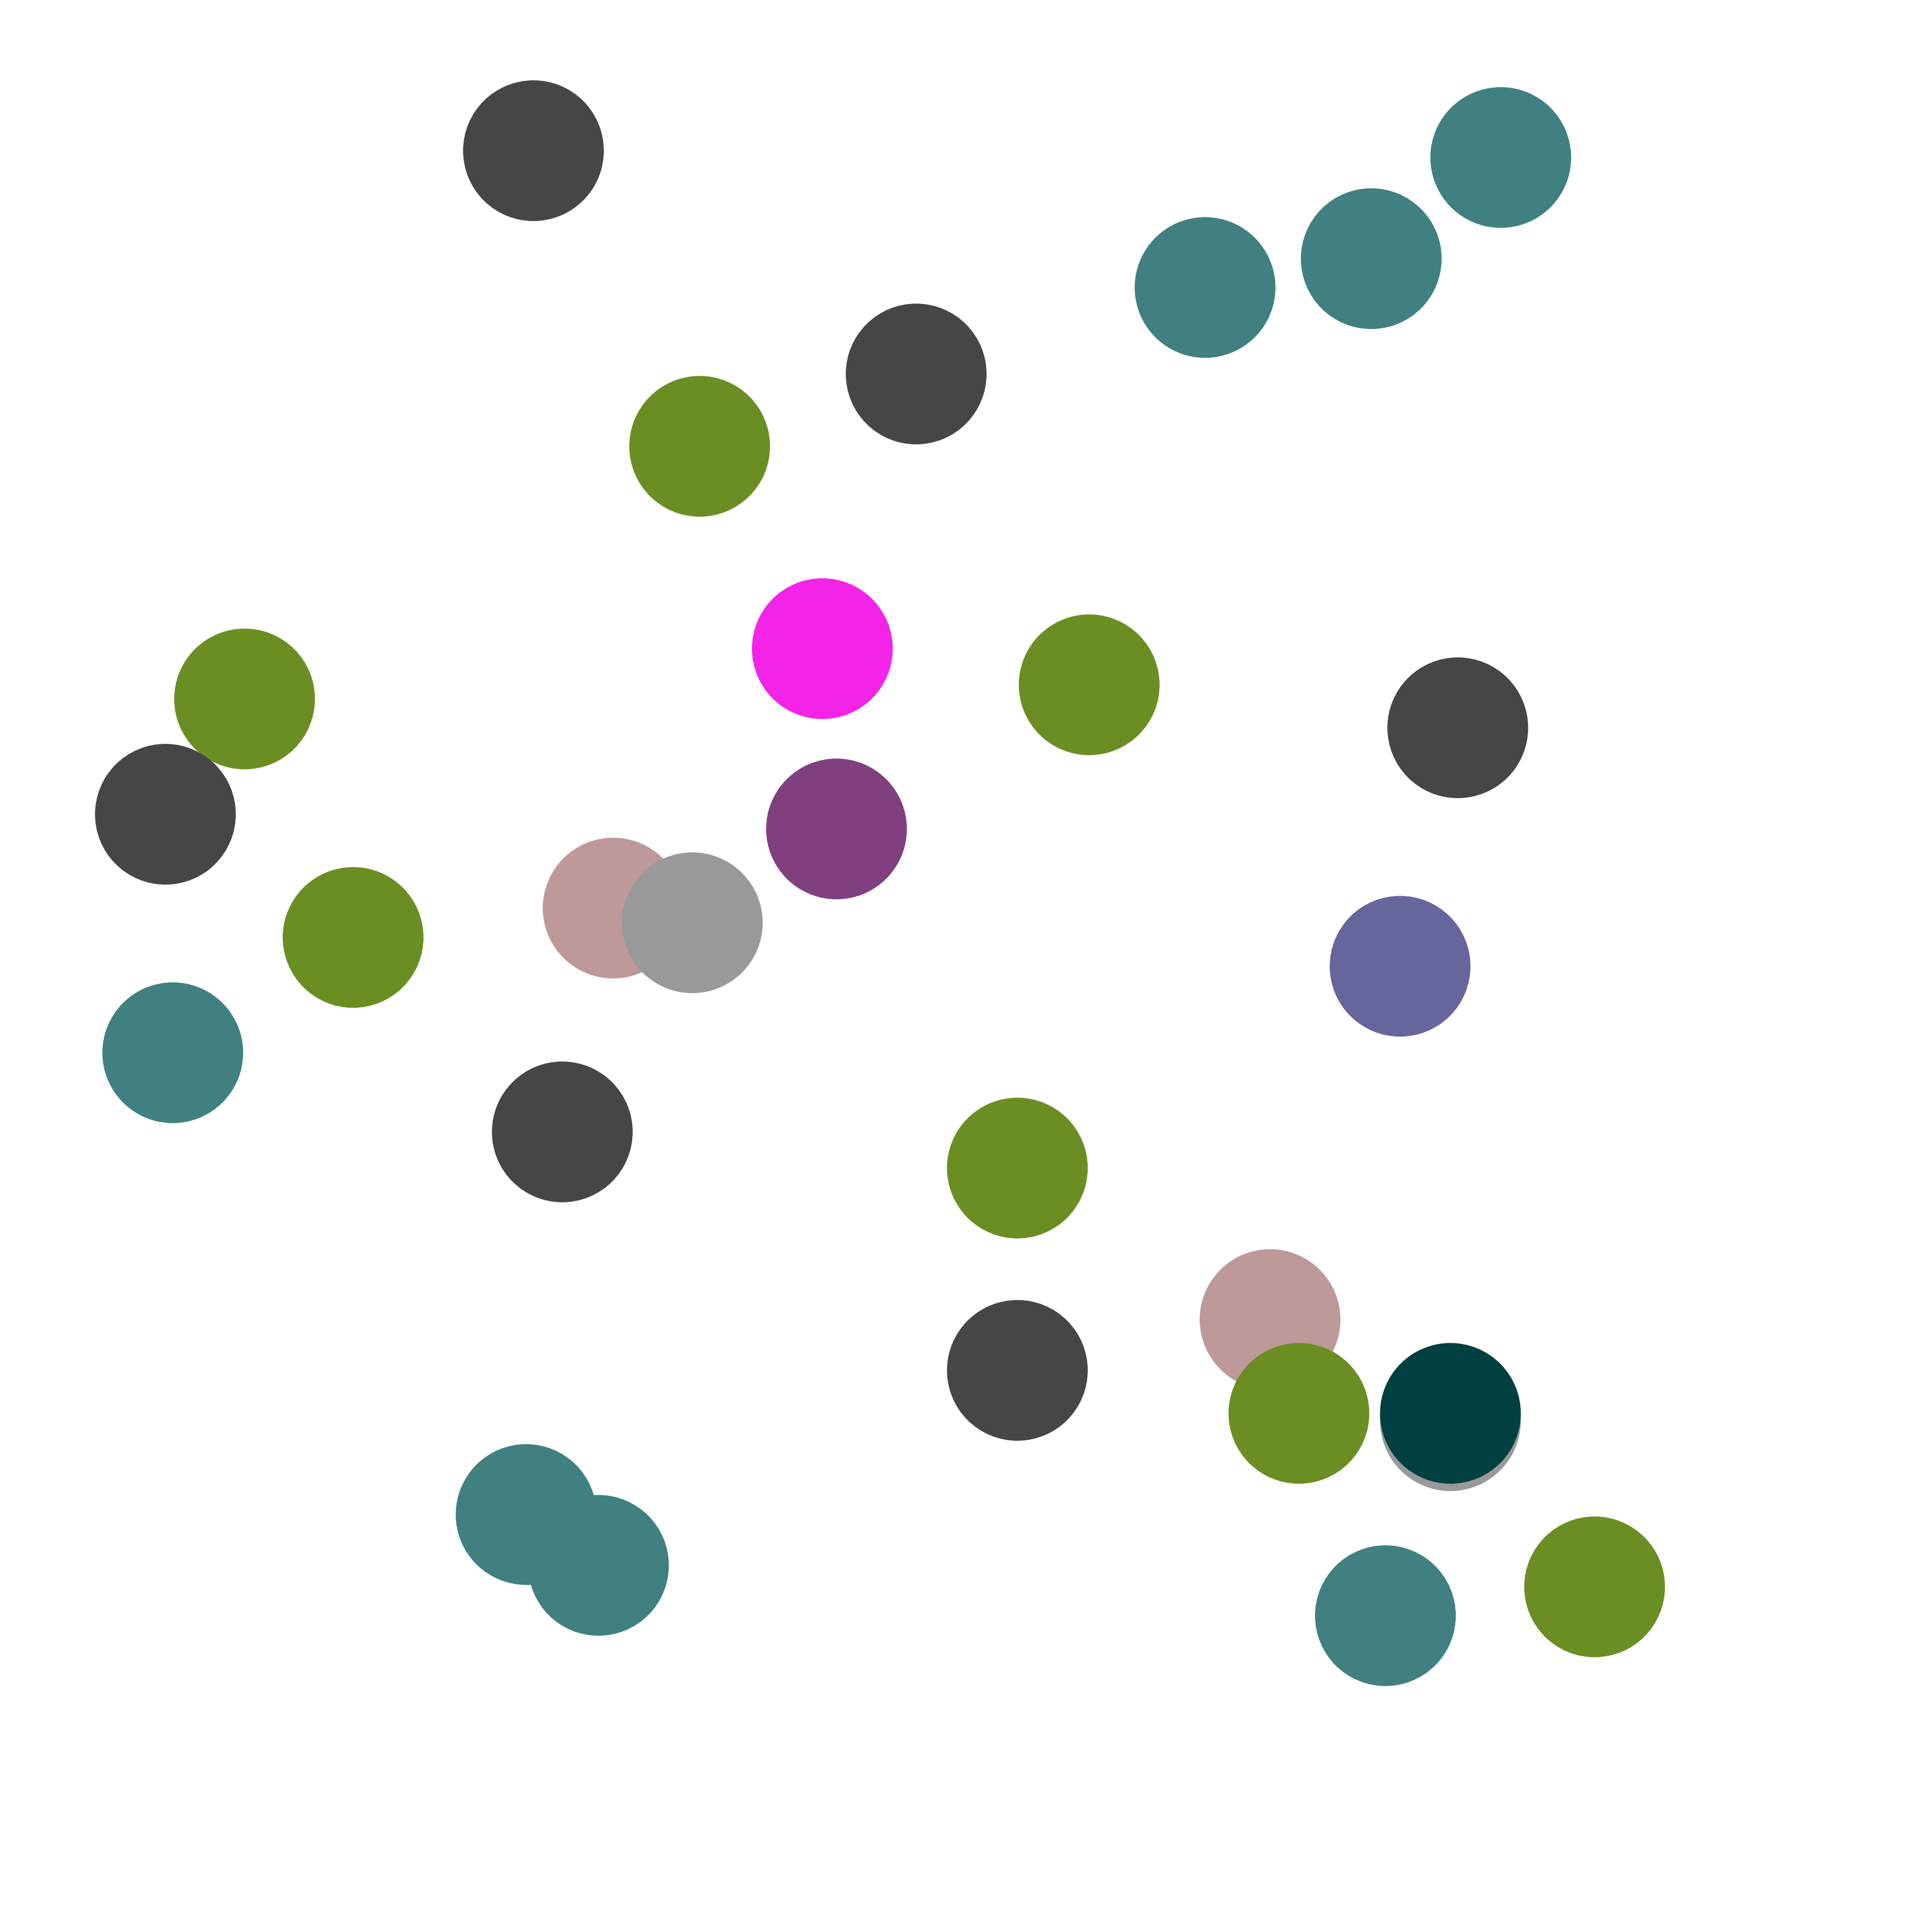

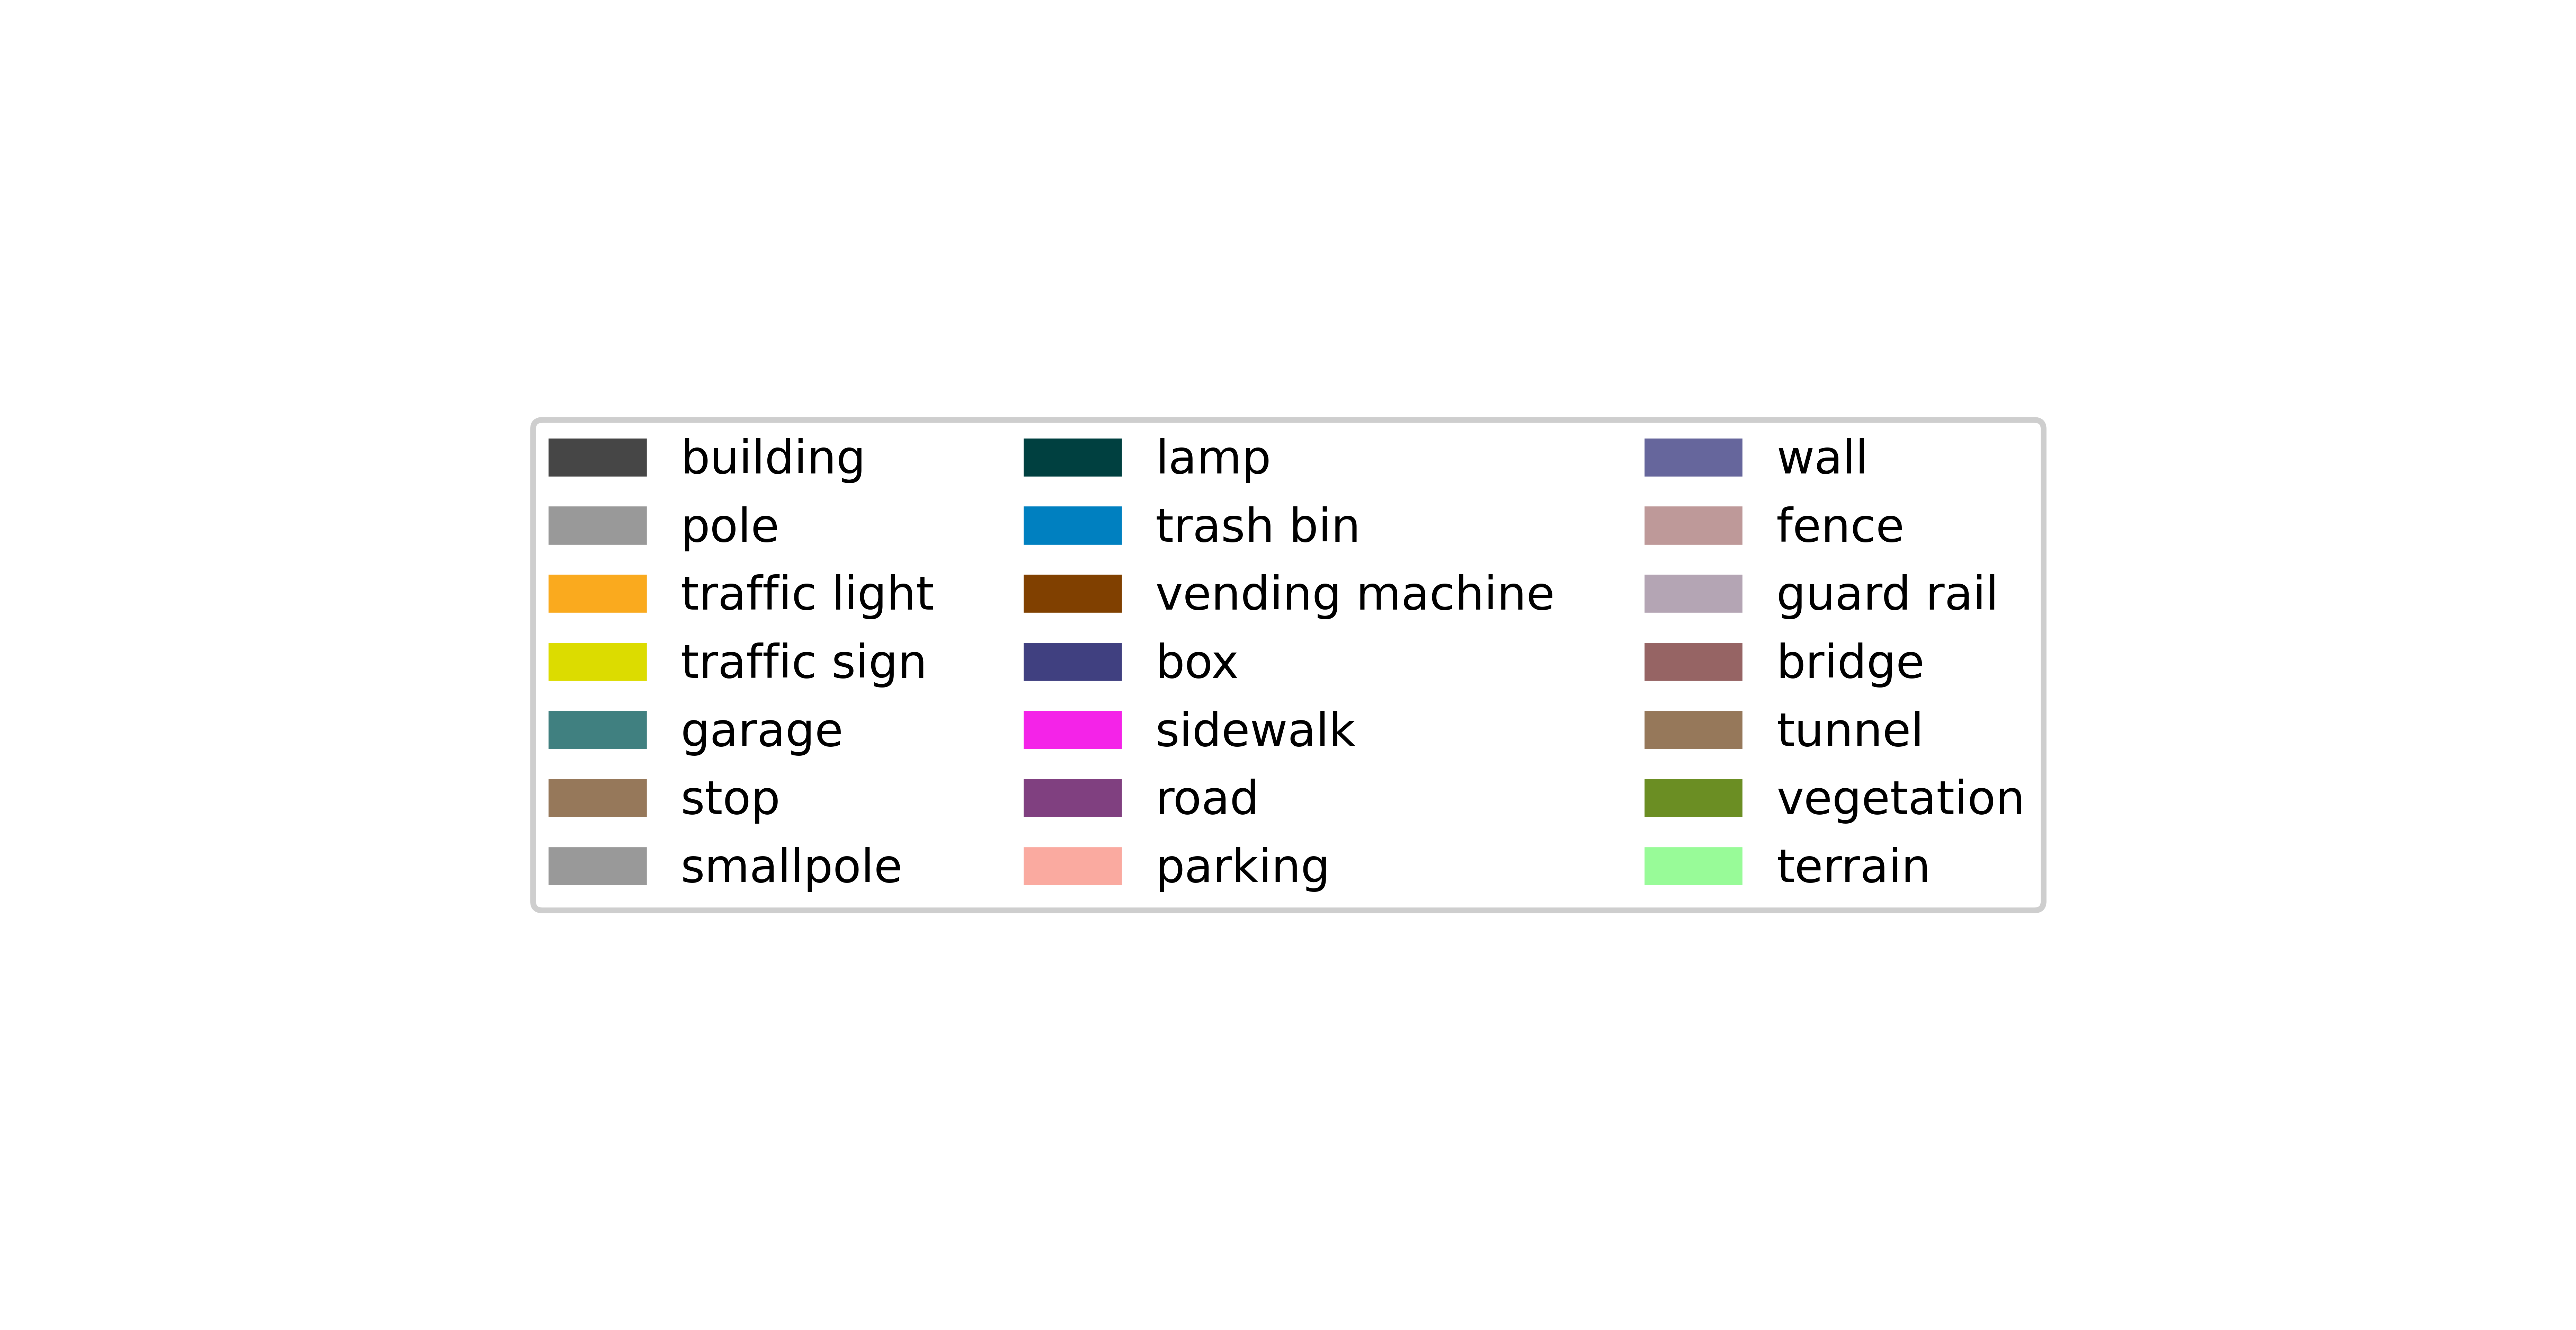

In [1]:
# -*- coding: utf-8 -*-
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ====== 固定类别颜色表 ======
CLASS_TO_COLOR = {
    "building": (70, 70, 70),
    "pole": (153, 153, 153),
    "traffic light": (250, 170, 30),
    "traffic sign": (220, 220, 0),
    "garage": (64, 128, 128),
    "stop": (150, 120, 90),
    "smallpole": (153, 153, 153),
    "lamp": (0, 64, 64),
    "trash bin": (0, 128, 192),
    "vending machine": (128, 64, 0),
    "box": (64, 64, 128),
    "sidewalk": (244, 35, 232),
    "road": (128, 64, 128),
    "parking": (250, 170, 160),
    "wall": (102, 102, 156),
    "fence": (190, 153, 153),
    "guard rail": (180, 165, 180),
    "bridge": (150, 100, 100),
    "tunnel": (150, 120, 90),
    "vegetation": (107, 142, 35),
    "terrain": (152, 251, 152),
    "_pose": (255, 255, 255),
}

def to_rgb01(rgb255):
    """(R,G,B) in 0-255 -> 0-1"""
    return tuple(np.array(rgb255, dtype=float) / 255.0)

# ====== 读取数据 ======
center_path = '/data/kang/vlmloc/vlmloc_data_v5/k360_50-10_gridCells_pd10_pc2_shiftPoses_all_nm-6_v5/2013_05_28_drive_0000_sync_centers_info.pkl'
with open(center_path, 'rb') as f:
    center_data = pickle.load(f)
nodes = center_data['centers_info'][200]

# ====== 主图：白底只画点（所有节点） ======
margin = 40
W = max(int(max(n['pixel_center'][0] for n in nodes) + margin), 256)
H = max(int(max(n['pixel_center'][1] for n in nodes) + margin), 256)
canvas = np.ones((H, W, 3), dtype=np.uint8) * 255

fig, ax = plt.subplots(figsize=(6, 6), dpi=600)
ax.imshow(canvas)
ax.set_axis_off()

for nd in nodes:
    x, y = nd['pixel_center']
    lab  = nd['label']
    color_rgb = to_rgb01(CLASS_TO_COLOR.get(lab, (0, 0, 0)))
    # 点：边框色 == 填充色
    ax.scatter([x], [y],
               s=1000,
               c=[color_rgb],
               edgecolors=[color_rgb],
               linewidths=0.6,
               zorder=3)

plt.tight_layout(pad=0.2)
# 可选导出
# plt.savefig("scene_points_only.png", dpi=300, bbox_inches='tight')
plt.show()

# ====== 图例单独绘制（除 _pose 外的所有语义） ======
legend_labels = [k for k in CLASS_TO_COLOR.keys() if k != "_pose"]
legend_patches = [
    Patch(facecolor=to_rgb01(CLASS_TO_COLOR[k]),
          edgecolor=to_rgb01(CLASS_TO_COLOR[k]),
          label=k)
    for k in legend_labels
]

# 调整图大小，dpi=600 高分辨率输出
fig_legend, ax_legend = plt.subplots(figsize=(6, 3), dpi=1200)
ax_legend.axis('off')

legend = ax_legend.legend(
    handles=legend_patches,
    loc='center',
    ncol=3,                # ✅ 4列排列
    fontsize=8,
    frameon=True,
    framealpha=0.95,
    # title="Classes",
    # title_fontsize=9
)

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)     # 去除subplot默认边距
plt.tight_layout(pad=0)                                  # 不额外添加空白
fig_legend.patch.set_alpha(0)      
# 可选导出
plt.savefig("scene_legend_only.svg",  bbox_inches='tight')
plt.show()


In [1]:
import numpy as np

retrieval_id_file = '/home/data_sata/vlmloc/CMMLoc-main/retrievals_coarse.npy'
retrieval_ids = np.load(retrieval_id_file)
print(f"Retrieval IDs shape: {retrieval_ids.shape}")
print(f"First 10 Retrieval IDs: {retrieval_ids[:10]}")

Retrieval IDs shape: (3246, 1)
First 10 Retrieval IDs: [['0010_00361']
 ['0010_00043']
 ['0010_00042']
 ['0010_00059']
 ['0010_00059']
 ['0010_00059']
 ['0010_00042']
 ['0010_00043']
 ['0010_00043']
 ['0010_00043']]


In [4]:
import os
import hashlib
from tqdm import tqdm

test_root = "/home/data_sata/vlmloc/Text2Loc/data/k360_50-10_gridCells_pd10_pc2_shiftPoses_all_nm-6_test"
v5_root = "/home/data_sata/vlmloc/Text2Loc/data/k360_50-10_gridCells_pd10_pc2_shiftPoses_all_nm-6_v5"


def get_all_files(root):
    file_list = []
    for dirpath, _, filenames in os.walk(root):
        for filename in filenames:
            abs_path = os.path.join(dirpath, filename)
            rel_path = os.path.relpath(abs_path, root)
            file_list.append(rel_path)
    return sorted(file_list)


def file_md5(path, chunk_size=1024 * 1024):
    md5 = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            md5.update(chunk)
    return md5.hexdigest()


test_files = get_all_files(test_root)

same_files = []
diff_files = []
missing_files = []

for rel_path in tqdm(test_files, desc="Comparing files"):
    test_path = os.path.join(test_root, rel_path)
    v5_path = os.path.join(v5_root, rel_path)

    if not os.path.exists(v5_path):
        missing_files.append(rel_path)
        continue

    # 先比较文件大小，不同则直接判定不同
    if os.path.getsize(test_path) != os.path.getsize(v5_path):
        diff_files.append(rel_path)
        continue

    # 大小相同再比较内容
    if file_md5(test_path) == file_md5(v5_path):
        same_files.append(rel_path)
    else:
        diff_files.append(rel_path)

print("\n===== Compare Summary =====")
print(f"Total files in test: {len(test_files)}")
print(f"Same files:          {len(same_files)}")
print(f"Different files:     {len(diff_files)}")
print(f"Missing in v5:       {len(missing_files)}")

if diff_files:
    print("\nDifferent files:")
    for p in diff_files:
        print(p)

if missing_files:
    print("\nMissing files in v5:")
    for p in missing_files:
        print(p)

Comparing files: 100%|██████████| 1039/1039 [01:06<00:00, 15.74it/s]


===== Compare Summary =====
Total files in test: 1039
Same files:          1039
Different files:     0
Missing in v5:       0


In [9]:
# Compare original CityLoc-K and new CityLoc-K
ori_path = '/home/data_sata/vlmloc/vlm-loc/Text2Loc/data/k360_50-10_gridCells_pd10_pc2_shiftPoses_all_nm-6_v5'
test_path = '/home/data_sata/vlmloc/vlm-loc/test_data/k360_50-10_gridCells_pd10_pc2_shiftPoses_all_nm-6_cityrefer_0310'

import os
import pickle
import numpy as np

target_files = [
    "2013_05_28_drive_0003_sync.pkl"
]

for subdir, name in [("cells", "cells"), ("objects", "objects"), ("poses", "poses")]:
    ori_subdir = os.path.join(ori_path, subdir)
    test_subdir = os.path.join(test_path, subdir)

    print(f"\n[{name}]")
    for file_name in target_files:
        with open(os.path.join(ori_subdir, file_name), "rb") as f:
            ori_data = pickle.load(f)
        with open(os.path.join(test_subdir, file_name), "rb") as f:
            test_data = pickle.load(f)

        same_len = len(ori_data) == len(test_data)
        print(f"{file_name}: ori={len(ori_data)}, test={len(test_data)}, same={same_len}")

        if subdir == "poses" and not same_len:
            print("Length mismatch detected. Comparing pose_w in sorted ascending order...")

            ori_pose_ws = sorted(
                [tuple(np.asarray(x.pose_w).reshape(-1).tolist()) for x in ori_data]
            )
            test_pose_ws = sorted(
                [tuple(np.asarray(x.pose_w).reshape(-1).tolist()) for x in test_data]
            )

            min_len = min(len(ori_pose_ws), len(test_pose_ws))
            mismatch_count = 0

            for i in range(min_len):
                if ori_pose_ws[i] != test_pose_ws[i]:
                    mismatch_count += 1
                    print(f"  pose_w mismatch at sorted index {i}")
                    print(f"    ori : {np.array(ori_pose_ws[i])}")
                    print(f"    test: {np.array(test_pose_ws[i])}")

            if len(ori_pose_ws) > min_len:
                print(f"  ori has {len(ori_pose_ws) - min_len} extra poses")
                for i in range(min_len, len(ori_pose_ws)):
                    print(f"    extra ori sorted index {i}: {np.array(ori_pose_ws[i])}")

            if len(test_pose_ws) > min_len:
                print(f"  test has {len(test_pose_ws) - min_len} extra poses")
                for i in range(min_len, len(test_pose_ws)):
                    print(f"    extra test sorted index {i}: {np.array(test_pose_ws[i])}")

            if mismatch_count == 0:
                print("  All overlapping pose_w are identical after sorting.")


[cells]
2013_05_28_drive_0003_sync.pkl: ori=106, test=106, same=True

[objects]
2013_05_28_drive_0003_sync.pkl: ori=160, test=160, same=True

[poses]
2013_05_28_drive_0003_sync.pkl: ori=612, test=612, same=True


In [6]:
# Compare original CityLoc-K and new CityLoc-K
ori_path = '/home/data_sata/vlmloc/CityRefer/data/sensaturban/cityrefer_data_v3'
test_path = '/home/data_sata/vlmloc/CityRefer/data/sensaturban/cityrefer_data_0310_test'
test_path = '/home/data_sata/vlmloc/vlm-loc/test_data/k360_50-10_gridCells_pd10_pc2_shiftPoses_all_nm-6_cityrefer_0310'
import os
import pickle
import numpy as np

target_files = [
    "birmingham_block_0_inst.pkl"
]

for subdir, name in [("cells", "cells"), ("objects", "objects"), ("poses", "poses")]:
    ori_subdir = os.path.join(ori_path, subdir)
    test_subdir = os.path.join(test_path, subdir)

    print(f"\n[{name}]")
    for file_name in target_files:
        with open(os.path.join(ori_subdir, file_name), "rb") as f:
            ori_data = pickle.load(f)
        with open(os.path.join(test_subdir, file_name), "rb") as f:
            test_data = pickle.load(f)

        same_len = len(ori_data) == len(test_data)
        print(f"{file_name}: ori={len(ori_data)}, test={len(test_data)}, same={same_len}")

        if subdir == "poses" and not same_len:
            print("Length mismatch detected. Comparing pose_w in sorted ascending order...")

            ori_pose_ws = sorted(
                [tuple(np.asarray(x.pose_w).reshape(-1).tolist()) for x in ori_data]
            )
            test_pose_ws = sorted(
                [tuple(np.asarray(x.pose_w).reshape(-1).tolist()) for x in test_data]
            )

            min_len = min(len(ori_pose_ws), len(test_pose_ws))
            mismatch_count = 0

            for i in range(min_len):
                if ori_pose_ws[i] != test_pose_ws[i]:
                    mismatch_count += 1
                    print(f"  pose_w mismatch at sorted index {i}")
                    print(f"    ori : {np.array(ori_pose_ws[i])}")
                    print(f"    test: {np.array(test_pose_ws[i])}")

            if len(ori_pose_ws) > min_len:
                print(f"  ori has {len(ori_pose_ws) - min_len} extra poses")
                for i in range(min_len, len(ori_pose_ws)):
                    print(f"    extra ori sorted index {i}: {np.array(ori_pose_ws[i])}")

            if len(test_pose_ws) > min_len:
                print(f"  test has {len(test_pose_ws) - min_len} extra poses")
                for i in range(min_len, len(test_pose_ws)):
                    print(f"    extra test sorted index {i}: {np.array(test_pose_ws[i])}")

            if mismatch_count == 0:
                print("  All overlapping pose_w are identical after sorting.")


[cells]
birmingham_block_0_inst.pkl: ori=17, test=17, same=True

[objects]
birmingham_block_0_inst.pkl: ori=196, test=196, same=True

[poses]
birmingham_block_0_inst.pkl: ori=101, test=101, same=True
